In [2]:
!mkdir -p ~/.kaggle
!mv kaggle.json ~/.kaggle/
!chmod 600 ~/.kaggle/kaggle.json



mv: cannot stat 'kaggle.json': No such file or directory
chmod: cannot access '/root/.kaggle/kaggle.json': No such file or directory


In [3]:
!pip install -q kaggle


In [4]:
# This cell previously attempted to unzip dogs-vs-cats.zip, which is not necessary as the dataset was downloaded unzipped.
# The unzipping code has been removed.

In [5]:
import kagglehub

# Download latest version
path = kagglehub.dataset_download("salader/dogs-vs-cats")

print("Path to dataset files:", path)

Path to dataset files: /kaggle/input/dogs-vs-cats


In [6]:
import zipfile
import os

# This cell previously attempted to unzip train.zip and test1.zip, which is not necessary as the dataset was downloaded unzipped.
# The unzipping code has been removed.

# You can directly access the images in the following directories:
# Training images: /kaggle/input/dogs-vs-cats/train
# Test images: /kaggle/input/dogs-vs-cats/test

print("✅ Unzipping steps removed as the data is already extracted.")

✅ Unzipping steps removed as the data is already extracted.


In [7]:
import os

train_dir = "/kaggle/input/dogs-vs-cats/train"

# Count the number of files in the training directory
num_train_files = len(os.listdir(train_dir))
print(f"Number of files in the training directory: {num_train_files}")

Number of files in the training directory: 2


In [8]:
from PIL import Image
import matplotlib.pyplot as plt
import os

# Correct the image path to point to the downloaded and unzipped location
img_path = "/kaggle/input/dogs-vs-cats/train/cat.0.jpg"

# Check if the file exists before trying to open it (optional but good practice)
if os.path.exists(img_path):
    img = Image.open(img_path)

    plt.imshow(img)
    plt.axis("off")
    plt.title("Sample Image")
    plt.show()
else:
    print(f"Error: Image file not found at {img_path}")

Error: Image file not found at /kaggle/input/dogs-vs-cats/train/cat.0.jpg


In [9]:

print(os.listdir("/kaggle/input/dogs-vs-cats/train")[:5])


['dogs', 'cats']


In [10]:
import tensorflow as tf
from tensorflow import keras
from tensorflow.keras.models import Sequential
from tensorflow.keras.layers import Conv2D, MaxPooling2D, Flatten, Dense,BatchNormalization,Dropout


In [11]:
train_ds=keras.utils.image_dataset_from_directory(
    directory="/kaggle/input/dogs-vs-cats/train",
    labels="inferred",
    label_mode="int",
    batch_size=32,
    image_size=(256, 256),
)

validation_ds=keras.utils.image_dataset_from_directory(
    directory="/kaggle/input/dogs-vs-cats/test",
    labels="inferred",
    label_mode="int",
    batch_size=32,
    image_size=(256, 256),
)

Found 20000 files belonging to 2 classes.
Found 5000 files belonging to 2 classes.


In [12]:
#normalise
def process(image,lable):
  image=tf.cast(image/255. ,tf.float32)
  return image,lable

train_ds=train_ds.map(process)
validation_ds=validation_ds.map(process)

In [13]:
#create cnn model
from tensorflow.keras.layers import BatchNormalization, Dropout

model=Sequential()

model.add(Conv2D(32,kernel_size=(3,3),padding="valid",activation="relu",input_shape=(256,256,3)))
model.add(BatchNormalization())
model.add(MaxPooling2D(pool_size=(2,2),strides=2,padding="valid"))

model.add(Conv2D(64,kernel_size=(3,3),padding="valid",activation="relu", ))
model.add(BatchNormalization())
model.add(MaxPooling2D(pool_size=(2,2),strides=2,padding="valid"))

model.add(Conv2D(128,kernel_size=(3,3),padding="valid",activation="relu", ))
model.add(BatchNormalization())
model.add(MaxPooling2D(pool_size=(2,2),strides=2,padding="valid"))

model.add(Flatten())

model.add(Dense(128,activation="relu"))
model.add(Dropout(0.1))
model.add(Dense(64,activation="relu"))
model.add(Dropout(0.1))
model.add(Dense(1,activation="sigmoid"))

/usr/local/lib/python3.11/dist-packages/keras/src/layers/convolutional/base_conv.py:107: UserWarning: Do not pass an `input_shape`/`input_dim` argument to a layer. When using Sequential models, prefer using an `Input(shape)` object as the first layer in the model instead.
  super().__init__(activity_regularizer=activity_regularizer, **kwargs)


In [14]:
model.summary()

Model: "sequential"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ conv2d (Conv2D)                 │ (None, 254, 254, 32)   │           896 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ batch_normalization             │ (None, 254, 254, 32)   │           128 │
│ (BatchNormalization)            │                        │               │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ max_pooling2d (MaxPooling2D)    │ (None, 127, 127, 32)   │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ conv2d_1 (Conv2D)               │ (None, 125, 125, 64)   │        18,496 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ batch_normalization_1           │ (None, 125, 125, 64)   │           256 │
│ (BatchNormalization)            │                        │               │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ max_pooling2d_1 (MaxPooling2D)  │ (None, 62, 62, 64)     │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ conv2d_2 (Conv2D)               │ (None, 60, 60, 128)    │        73,856 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ batch_normalization_2           │ (None, 60, 60, 128)    │           512 │
│ (BatchNormalization)            │                        │               │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ max_pooling2d_2 (MaxPooling2D)  │ (None, 30, 30, 128)    │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ flatten (Flatten)               │ (None, 115200)         │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense (Dense)                   │ (None, 128)            │    14,745,728 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout (Dropout)               │ (None, 128)            │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_1 (Dense)                 │ (None, 64)             │         8,256 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout_1 (Dropout)             │ (None, 64)             │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_2 (Dense)                 │ (None, 1)              │            65 │
└─────────────────────────────────┴────────────────────────┴───────────────┘

 Total params: 14,848,193 (56.64 MB)

 Trainable params: 14,847,745 (56.64 MB)

 Non-trainable params: 448 (1.75 KB)

In [15]:
model.compile(optimizer="adam",loss="binary_crossentropy",metrics=["accuracy"])

In [16]:
history=model.fit(train_ds,epochs=10,validation_data=validation_ds)

Epoch 1/10
625/625 ━━━━━━━━━━━━━━━━━━━━ 91s 128ms/step - accuracy: 0.5591 - loss: 2.4495 - val_accuracy: 0.6168 - val_loss: 0.6573
Epoch 2/10
625/625 ━━━━━━━━━━━━━━━━━━━━ 104s 80ms/step - accuracy: 0.6649 - loss: 0.6309 - val_accuracy: 0.6228 - val_loss: 0.6476
Epoch 3/10
625/625 ━━━━━━━━━━━━━━━━━━━━ 51s 81ms/step - accuracy: 0.6934 - loss: 0.5868 - val_accuracy: 0.6914 - val_loss: 0.5748
Epoch 4/10
625/625 ━━━━━━━━━━━━━━━━━━━━ 79s 76ms/step - accuracy: 0.7276 - loss: 0.5575 - val_accuracy: 0.7058 - val_loss: 0.5804
Epoch 5/10
625/625 ━━━━━━━━━━━━━━━━━━━━ 82s 76ms/step - accuracy: 0.7531 - loss: 0.5217 - val_accuracy: 0.6304 - val_loss: 0.7103
Epoch 6/10
625/625 ━━━━━━━━━━━━━━━━━━━━ 48s 76ms/step - accuracy: 0.7642 - loss: 0.5011 - val_accuracy: 0.7320 - val_loss: 0.5409
Epoch 7/10
625/625 ━━━━━━━━━━━━━━━━━━━━ 82s 76ms/step - accuracy: 0.7689 - loss: 0.4919 - val_accuracy: 0.7734 - val_loss: 0.4928
Epoch 8/10
625/625 ━━━━━━━━━━━━━━━━━━━━ 82s 77ms/step - accuracy: 0.7970 - loss: 0.4540 

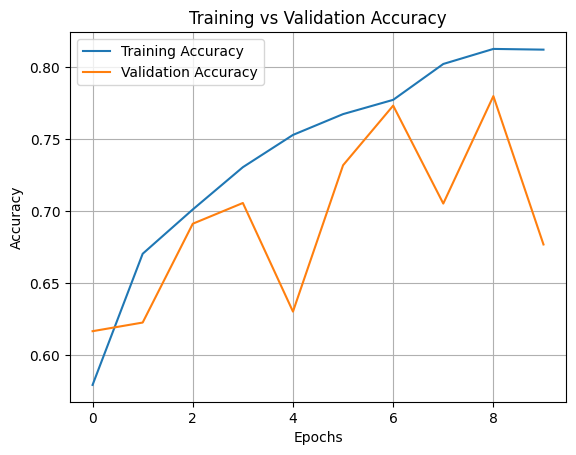

In [17]:
import matplotlib.pyplot as plt

# Plot training and validation accuracy
plt.plot(history.history['accuracy'], label='Training Accuracy')
plt.plot(history.history['val_accuracy'], label='Validation Accuracy')

plt.title('Training vs Validation Accuracy')
plt.xlabel('Epochs')
plt.ylabel('Accuracy')
plt.legend()
plt.grid(True)
plt.show()


In [18]:
import cv2

In [19]:
test_img=cv2.imread('/content/catt.jpg')

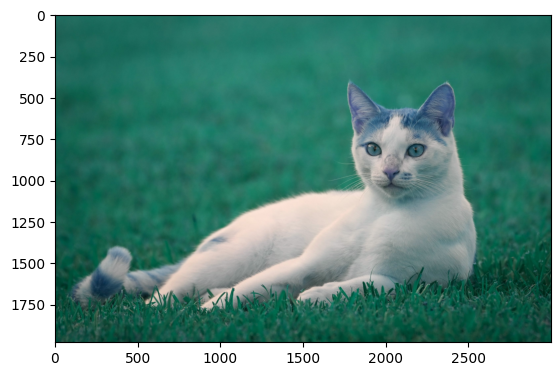

In [20]:
plt.imshow(test_img)

In [21]:
test_img.shape

(1977, 3000, 3)

In [22]:
test_img=cv2.resize(test_img,(256,256))

In [23]:
test_input=test_img.reshape((1,256,256,3))

In [26]:
model.predict(test_input)

1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 30ms/step


array([[0.11761501]], dtype=float32)

In [27]:
print("Final Training Accuracy:", history.history['accuracy'][-1])
print("Final Validation Accuracy:", history.history['val_accuracy'][-1])


Final Training Accuracy: 0.812250018119812
Final Validation Accuracy: 0.6769999861717224
